# Baseline models

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv('../data/clean/full_data.csv')

In [3]:
df.head()

,casos,week-canton,relative_risk,urb,tmax_min,tmax_max,tmax_mean,tmax_median,tmin_min,tmin_max,tmin_mean,tmin_median,precip_total,precip_min,precip_max,precip_mean,precip_median
0,2,2020-1-507,3.011235,0,31.206179,34.216175,32.980368,33.278346,31.206179,34.216175,32.980368,33.278346,16.483572,0.0,8.394386,0.686816,0.0
1,0,2020-1-112,0.000000,2,27.300568,31.489710,28.930743,28.016085,27.300568,31.489710,28.930743,28.016085,77.464812,0.0,37.667015,6.455401,0.0
2,29,2020-1-201,2.763229,1,21.756056,29.411386,26.367157,27.010843,21.756056,29.411386,26.367157,27.010843,56.828430,0.0,32.674007,3.551777,0.0
3,4,2020-1-110,1.288112,1,23.514788,24.153862,23.886117,23.937909,23.514788,24.153862,23.886117,23.937909,11.819548,0.0,11.819548,2.954887,0.0
4,0,2020-1-306,0.000000,2,23.673475,24.585056,24.102187,24.075108,23.673475,24.585056,24.102187,24.075108,27.596506,0.0,27.596506,6.899127,0.0


In [20]:
# CHANGE THIS WHEN THE DATA IS OK, THIS IS BASICALLY A SIN TO GET THE MODEL TO WORK
df.drop(columns=['relative_risk'], inplace=True)
df.dropna(inplace=True)

In [21]:
df.shape

(18662, 16)

In [22]:
df = pd.get_dummies(df, columns = ["urb"])

In [23]:
df.head()

,casos,week-canton,tmax_min,tmax_max,tmax_mean,tmax_median,tmin_min,tmin_max,tmin_mean,tmin_median,precip_total,precip_min,precip_max,precip_mean,precip_median,urb_0,urb_1,urb_2
0,2,2020-1-507,31.206179,34.216175,32.980368,33.278346,31.206179,34.216175,32.980368,33.278346,16.483572,0.0,8.394386,0.686816,0.0,True,False,False
1,0,2020-1-112,27.300568,31.489710,28.930743,28.016085,27.300568,31.489710,28.930743,28.016085,77.464812,0.0,37.667015,6.455401,0.0,False,False,True
2,29,2020-1-201,21.756056,29.411386,26.367157,27.010843,21.756056,29.411386,26.367157,27.010843,56.828430,0.0,32.674007,3.551777,0.0,False,True,False
3,4,2020-1-110,23.514788,24.153862,23.886117,23.937909,23.514788,24.153862,23.886117,23.937909,11.819548,0.0,11.819548,2.954887,0.0,False,True,False
4,0,2020-1-306,23.673475,24.585056,24.102187,24.075108,23.673475,24.585056,24.102187,24.075108,27.596506,0.0,27.596506,6.899127,0.0,False,False,True


In [62]:
train = df[df['week-canton'] < '2024-1-101']
val = df[(df['week-canton'] >= '2024-1-101') & (df['week-canton'] < '2025-1-101')]
test = df[df['week-canton'] >= '2025-1-101']

X_train = train.drop(columns = ["casos", "week-canton"])
y_train = train['casos']

X_val = val.drop(columns = ["casos", "week-canton"])
y_val= val['casos']

X_test= test.drop(columns = ["casos", "week-canton"])
y_test = test['casos']

In [39]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [40]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [12]:
train.shape, val.shape, test.shape

((13020, 18), (3224, 18), (2418, 18))

## Case number
### Linear regression

In [41]:
reg = LinearRegression().fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

In [42]:
r2_reg = r2_score(y_test_for_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_for_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_for_reg, y_pred_reg)
rmse_reg = mse_reg ** 0.5

In [43]:
print(f"""R2 reg: {round(r2_reg, 3)}
MAE reg: {round(mae_reg, 3)}
MSE reg: {round(mse_reg, 3)}
RMSE reg: {round(rmse_reg, 3)}
      """)

R2 reg: 0.016
MAE reg: 5.507
MSE reg: 174.82
RMSE reg: 13.222
      


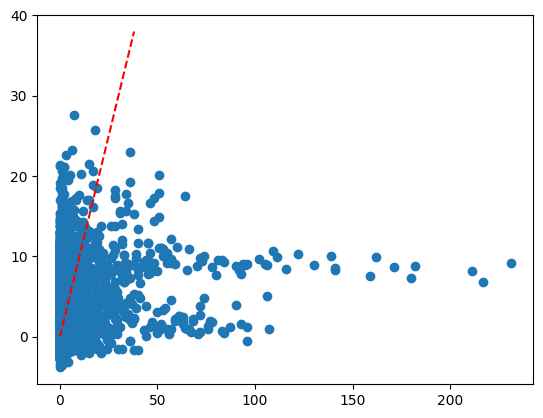

In [59]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_reg)

In [65]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_})
coef_reg_sorted = coef_df.sort_values(by = "Coefficient", ascending=False)

coef_reg_sorted

,Feature,Coefficient
3,tmax_median,1.692579
7,tmin_median,1.692579
8,precip_total,1.421617
11,precip_mean,1.268519
14,urb_1,0.753813
6,tmin_mean,0.654008
2,tmax_mean,0.654008
5,tmin_max,0.477644
1,tmax_max,0.477644
9,precip_min,-0.125814


Text(0.5, 0, 'Coefficient')

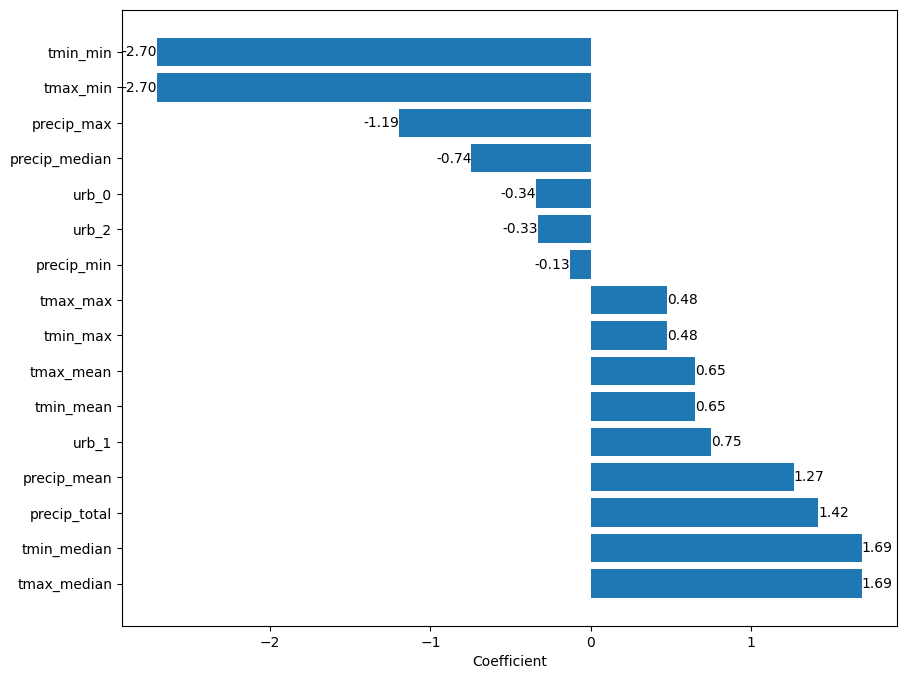

In [74]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(coef_reg_sorted["Feature"], coef_reg_sorted["Coefficient"])
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [56]:
rf = RandomForestRegressor().fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_for_reg_scaled)

In [57]:
mae_rf = mean_absolute_error(y_test_for_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_for_reg, y_pred_rf)
rmse_rf = mse_reg ** 0.5

In [58]:
print(f"""MAE reg: {round(mae_rf, 3)}
MSE reg: {round(mse_rf, 3)}
RMSE reg: {round(rmse_rf, 3)}
      """)

MAE reg: 5.648
MSE reg: 178.322
RMSE reg: 13.222
      


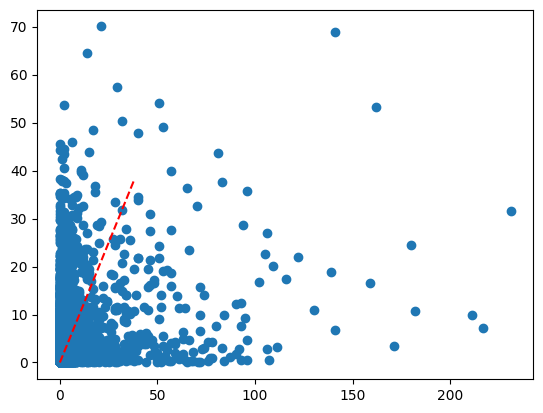

In [60]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_rf)

In [67]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
8,precip_total,0.162033
10,precip_max,0.098972
4,tmin_min,0.089193
0,tmax_min,0.087869
11,precip_mean,0.075441
1,tmax_max,0.073096
5,tmin_max,0.071926
3,tmax_median,0.068769
7,tmin_median,0.065558
2,tmax_mean,0.059313


Text(0.5, 0, 'Importance')

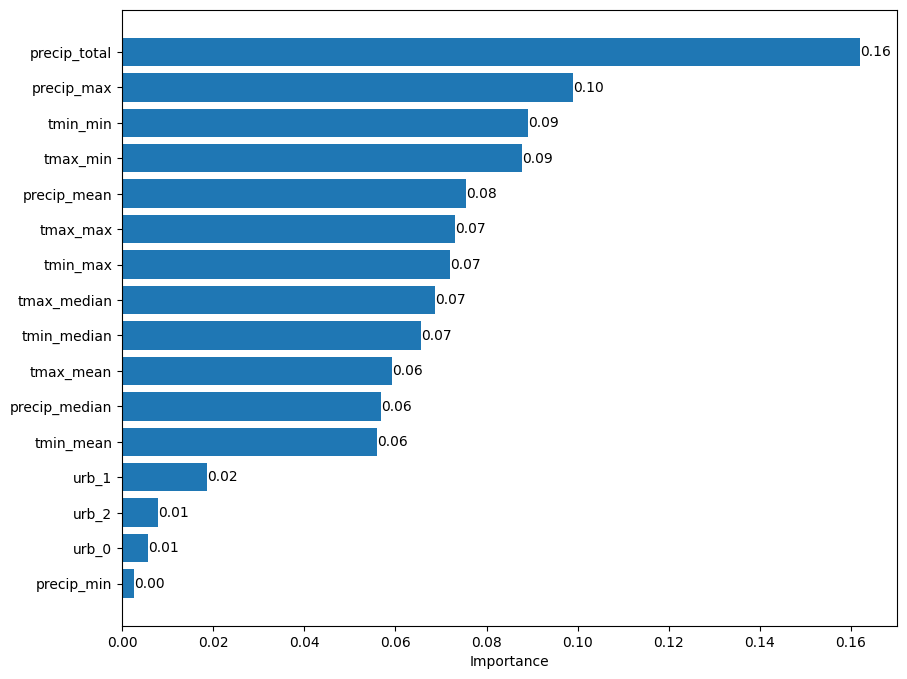

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"], imp_rf_sorted["Importance"])
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")